Raw-X  draws: 1000  |  Std-X draws: 20000


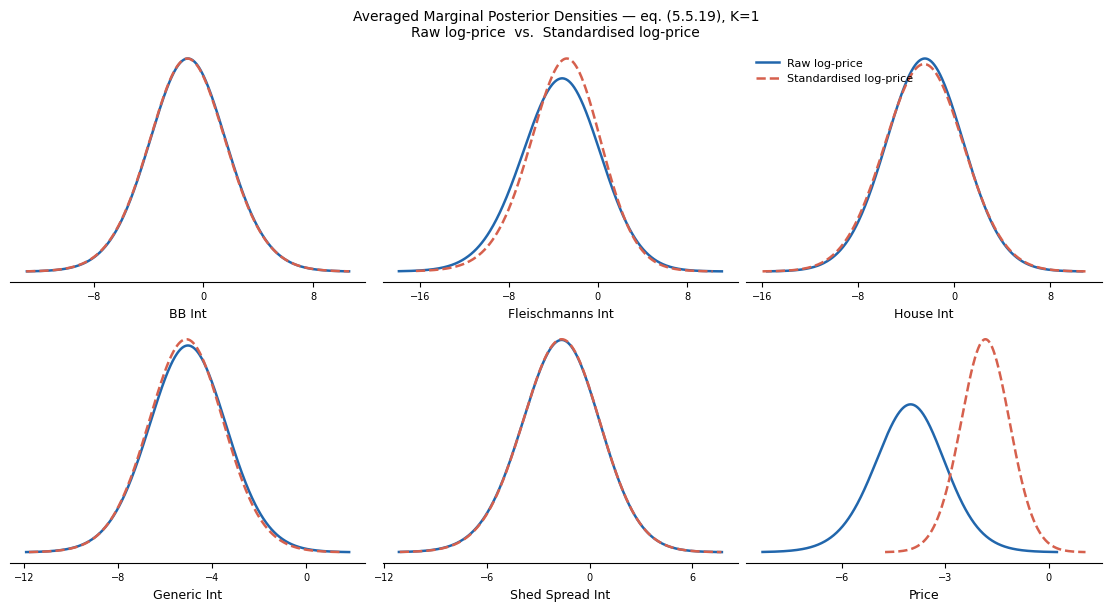

In [1]:
import pathlib
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import norm

# ── 1. Load posterior draws from BOTH models ─────────────────────────────────

data_dir = pathlib.Path('Data')

def load_model(filename):
    rdata   = pyreadr.read_r(str(data_dir / filename))
    mu      = rdata['mu_draws_df'].values.astype(float)    # (R, 6)
    cov     = rdata['cov_draws_df'].values.astype(float)   # (R, 36)
    return mu, cov

mu_raw, cov_raw = load_model('bayesm_output_margarine_1comp_rawX.RData')
mu_std, cov_std = load_model('bayesm_output_margarine_1comp_stdX.RData')

print(f"Raw-X  draws: {mu_raw.shape[0]}  |  Std-X draws: {mu_std.shape[0]}")

# ── 2. Helper: compute averaged marginal density for one model ────────────────

def averaged_marginal_densities(mu, cov, N_GRID=600):
    """
    Implements eq. (5.5.19) for K=1:
      d̄_j(x) = (1/R) Σ_r  N(x ; μ_r[j], √Σ_r[j,j])

    Returns lists of grids and density arrays, one per parameter.
    """
    nvar = mu.shape[1]
    diag_idx = np.array([j * nvar + j for j in range(nvar)])
    std_diag = np.sqrt(cov[:, diag_idx])   # (R, nvar)

    grids, densities = [], []
    for j in range(nvar):
        mu_j  = mu[:, j]
        std_j = std_diag[:, j]

        # Grid spans ± 4 pooled SDs, centred on the posterior mean of μ_j
        spread = np.sqrt(std_j.mean()**2 + mu_j.var())
        centre = mu_j.mean()
        x = np.linspace(centre - 4 * spread, centre + 4 * spread, N_GRID)

        pdf_matrix = norm.pdf(
            x[:, None],           # (N_GRID, 1)
            loc=mu_j[None, :],    # (1, R)
            scale=std_j[None, :]  # (1, R)
        )                          # (N_GRID, R)

        grids.append(x)
        densities.append(pdf_matrix.mean(axis=1))   # (N_GRID,)

    return grids, densities

grids_raw, dens_raw = averaged_marginal_densities(mu_raw, cov_raw)
grids_std, dens_std = averaged_marginal_densities(mu_std, cov_std)

# ── 3. Plot ───────────────────────────────────────────────────────────────────

plot_labels = [
    'BB Int', 'Fleischmanns Int', 'House Int',
    'Generic Int', 'Shed Spread Int', 'Price'
]

# Style config — easy to tweak
STYLE = {
    'raw': dict(color='#2166ac', linewidth=1.8, linestyle='-',  label='Raw log-price'),
    'std': dict(color='#d6604d', linewidth=1.8, linestyle='--', label='Standardised log-price'),
}

fig, axes = plt.subplots(
    nrows=2, ncols=3,
    figsize=(11, 6),
    constrained_layout=True
)

for idx, ax in enumerate(axes.flat):
    ax.plot(grids_raw[idx], dens_raw[idx], **STYLE['raw'])
    ax.plot(grids_std[idx], dens_std[idx], **STYLE['std'])

    ax.set_xlabel(plot_labels[idx], fontsize=9)
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=7)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4, integer=False))

# Single shared legend in the top-right panel
axes[0, 2].legend(
    fontsize=8,
    frameon=False,
    loc='upper left'
)

fig.suptitle(
    'Averaged Marginal Posterior Densities — eq. (5.5.19), K=1\n'
    'Raw log-price  vs.  Standardised log-price',
    fontsize=10
)

plt.show()